## 제외 칼럼
- transaction_id
- user_id
- addiction_level

num_features = [
    'age','daily_screen_time_hours','social_medai_hours','gaming_hours',
    'work_study_hours','sleep_hours','notifications_per_day','app_opens_per_day','weekend_screen_time'
]
onehot_features = ['gender']
binary_features = ['academic_work_impact']

num_features에 대해서 다양한 scaling 적용 후 성능 평가

첫번째는 모든 feature에 대해서 standard scaling 적용


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

Mounted at /content/drive


In [2]:
df = df.drop(columns=['transaction_id', 'user_id', 'addiction_level'])
print(df.columns)
X = df.drop(columns=['addicted_label'])
y = df['addicted_label']

Index(['age', 'gender', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')


In [3]:
num_features = [
    'age','daily_screen_time_hours','social_media_hours','gaming_hours',
    'work_study_hours','sleep_hours','notifications_per_day','app_opens_per_day','weekend_screen_time'
]
onehot_features = ['gender']
binary_features = ['academic_work_impact']

X = df[num_features + onehot_features + binary_features]
y = df['addicted_label']

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler


preprocessor = ColumnTransformer(
    transformers=[
        ('num','passthrough', num_features),
        ('gender', OneHotEncoder(handle_unknown='ignore'),onehot_features),
        ('impact', OrdinalEncoder(categories=[['No', 'Yes']]), binary_features)
    ]
)

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        # C=C
        # class_weight = cw
        # class_weight = 'balanced',
        max_iter=1000
    ))
])

# 5-fold cross validation 예측값 생성
y_pred = cross_val_predict(
    model,
    X,
    y,
    cv=cv
)

print("Accuracy:", accuracy_score(y, y_pred))
print("Precision:", precision_score(y, y_pred, average='weighted'))
print("Recall:", recall_score(y, y_pred, average='weighted'))
print("F1-score:", f1_score(y, y_pred, average='weighted'))

print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Accuracy: 0.8913333333333333
Precision: 0.890006992479461
Recall: 0.8913333333333333
F1-score: 0.8903872333644071

Confusion Matrix:
[[1723  469]
 [ 346 4962]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


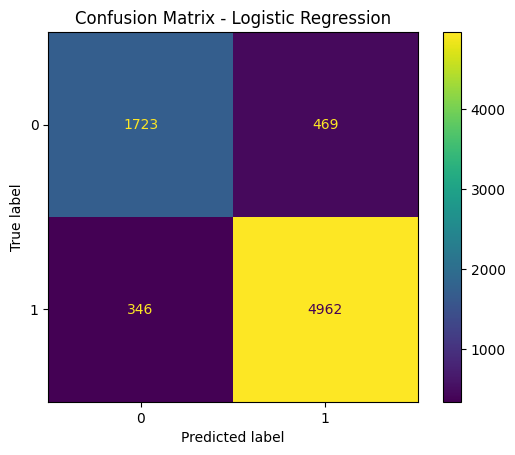

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['0', '1']
)

disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scalers = {
    'None': 'passthrough',
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

C_values = [0.01, 0.1, 1, 10, 100]
class_weights = [None, 'balanced']
penalties = ['l1', 'l2']
results = []

for scaler_name, scaler in scalers.items():
    for C in C_values:
        for cw in class_weights:

            preprocessor = ColumnTransformer(
                transformers=[
                    ('num', scaler, num_features),
                    ('gender', OneHotEncoder(handle_unknown='ignore'), onehot_features),
                    ('impact', OrdinalEncoder(categories=[['No', 'Yes']]), binary_features)
                ]
            )

            model = Pipeline(steps=[
                ('preprocess', preprocessor),
                ('classifier', LogisticRegression(
                    penalty=penalty,
                    solver='liblinear',
                    C=C,
                    class_weight=cw,
                ))
            ]) 

            y_pred = cross_val_predict(model, X, y, cv=cv)

            results.append({
                'Scaler': scaler_name,
                'C': C,
                'class_weight': cw,
                'Accuracy': accuracy_score(y, y_pred),
                'Precision_weighted': precision_score(y, y_pred, average='weighted', zero_division=0),
                'Recall_weighted': recall_score(y, y_pred, average='weighted', zero_division=0),
                'F1_weighted': f1_score(y, y_pred, average='weighted', zero_division=0)
            })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1_weighted', ascending=False)

print(results_df)

            Scaler       C class_weight  Accuracy  Precision_weighted  \
16  StandardScaler   10.00         None  0.891600            0.890292   
38    RobustScaler  100.00         None  0.891600            0.890292   
18  StandardScaler  100.00         None  0.891600            0.890292   
26    MinMaxScaler   10.00         None  0.891600            0.890265   
8             None  100.00         None  0.891467            0.890164   
28    MinMaxScaler  100.00         None  0.891467            0.890150   
14  StandardScaler    1.00         None  0.891333            0.890035   
36    RobustScaler   10.00         None  0.891333            0.890021   
6             None   10.00         None  0.891067            0.889722   
4             None    1.00         None  0.891333            0.889801   
34    RobustScaler    1.00         None  0.890667            0.889294   
24    MinMaxScaler    1.00         None  0.890800            0.889220   
12  StandardScaler    0.10         None  0.890267  

In [ ]:
# top1 모델만 threshold 실험
thresholds = np.arange(0.01, 1.00, 0.001)

threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)

    threshold_results.append({
        'Threshold': round(t, 3),
        'Accuracy': accuracy_score(y, y_pred_t),
        'Precision_weighted': precision_score(y, y_pred_t, average='weighted', zero_division=0),
        'Recall_weighted': recall_score(y, y_pred_t, average='weighted', zero_division=0),
        'F1_weighted': f1_score(y, y_pred_t, average='weighted', zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.sort_values(by='F1_weighted', ascending=False)

print(threshold_df.head(20))

     Threshold  Accuracy  Precision_weighted  Recall_weighted  F1_weighted
455      0.465  0.893733            0.892140         0.893733     0.892031
454      0.464  0.893600            0.892002         0.893600     0.891869
458      0.468  0.893467            0.891867         0.893467     0.891829
456      0.466  0.893467            0.891864         0.893467     0.891777
453      0.463  0.893467            0.891864         0.893467     0.891725
460      0.470  0.893333            0.891731         0.893333     0.891719
457      0.467  0.893333            0.891728         0.893333     0.891685
461      0.471  0.893200            0.891595         0.893200     0.891592
459      0.469  0.893200            0.891593         0.893200     0.891575
466      0.476  0.893067            0.891469         0.893067     0.891534
464      0.474  0.893067            0.891463         0.893067     0.891500
470      0.480  0.892933            0.891354         0.892933     0.891492
480      0.490  0.892667 

In [17]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Top 10 model settings
top10_models = [
    {'Rank': 1,  'Scaler': 'StandardScaler', 'C': 10.00,  'class_weight': None},
    {'Rank': 2,  'Scaler': 'RobustScaler',   'C': 100.00, 'class_weight': None},
    {'Rank': 3,  'Scaler': 'StandardScaler', 'C': 100.00, 'class_weight': None},
    {'Rank': 4,  'Scaler': 'MinMaxScaler',   'C': 10.00,  'class_weight': None},
    {'Rank': 5,  'Scaler': 'None',           'C': 100.00, 'class_weight': None},
    {'Rank': 6,  'Scaler': 'MinMaxScaler',   'C': 100.00, 'class_weight': None},
    {'Rank': 7,  'Scaler': 'StandardScaler', 'C': 1.00,   'class_weight': None},
    {'Rank': 8,  'Scaler': 'RobustScaler',   'C': 10.00,  'class_weight': None},
    {'Rank': 9,  'Scaler': 'None',           'C': 10.00,  'class_weight': None},
    {'Rank': 10, 'Scaler': 'None',           'C': 1.00,   'class_weight': None}
]

# scaler mapping
scaler_dict = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'None': 'passthrough'
}

# threshold range: 0.45 ~ 0.50
thresholds = np.arange(0.45, 0.501, 0.001)

all_threshold_results = []
best_results = []

for setting in top10_models:
    rank = setting['Rank']
    scaler_name = setting['Scaler']
    C = setting['C']
    cw = setting['class_weight']
    
    scaler = scaler_dict[scaler_name]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', scaler, num_features),
            ('gender', OneHotEncoder(handle_unknown='ignore'), onehot_features),
            ('impact', OrdinalEncoder(categories=[['No', 'Yes']]), binary_features)
        ]
    )

    model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('classifier', LogisticRegression(
            C=C,
            class_weight=cw,
            max_iter=3000
        ))
    ])

    # probability prediction for class 1
    y_proba = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method='predict_proba'
    )[:, 1]

    model_threshold_results = []

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)

        result = {
            'Original_Rank': rank,
            'Scaler': scaler_name,
            'C': C,
            'class_weight': cw,
            'Threshold': round(t, 3),
            'Accuracy': accuracy_score(y, y_pred_t),
            'Precision_weighted': precision_score(y, y_pred_t, average='weighted', zero_division=0),
            'Recall_weighted': recall_score(y, y_pred_t, average='weighted', zero_division=0),
            'F1_weighted': f1_score(y, y_pred_t, average='weighted', zero_division=0)
        }

        all_threshold_results.append(result)
        model_threshold_results.append(result)

    # best threshold for this model
    model_threshold_df = pd.DataFrame(model_threshold_results)
    best_model_result = model_threshold_df.sort_values(
        by='F1_weighted',
        ascending=False
    ).iloc[0]

    best_results.append(best_model_result)

# 전체 threshold 결과
all_threshold_df = pd.DataFrame(all_threshold_results)

# 각 Top 10 모델별 best threshold 결과
best_threshold_top10_df = pd.DataFrame(best_results)
best_threshold_top10_df = best_threshold_top10_df.sort_values(
    by='F1_weighted',
    ascending=False
).reset_index(drop=True)

print("Top 10 models after threshold tuning:")
print(best_threshold_top10_df)

Top 10 models after threshold tuning:
   Original_Rank          Scaler      C class_weight  Threshold  Accuracy  \
0              9            None   10.0         None      0.488  0.893600   
1              8    RobustScaler   10.0         None      0.467  0.893867   
2              5            None  100.0         None      0.488  0.893333   
3              2    RobustScaler  100.0         None      0.487  0.893333   
4              7  StandardScaler    1.0         None      0.467  0.893733   
5              6    MinMaxScaler  100.0         None      0.468  0.893733   
6              1  StandardScaler   10.0         None      0.467  0.893733   
7             10            None    1.0         None      0.485  0.893333   
8              4    MinMaxScaler   10.0         None      0.465  0.893733   
9              3  StandardScaler  100.0         None      0.489  0.893067   

   Precision_weighted  Recall_weighted  F1_weighted  
0            0.892145         0.893600     0.892424  
1     

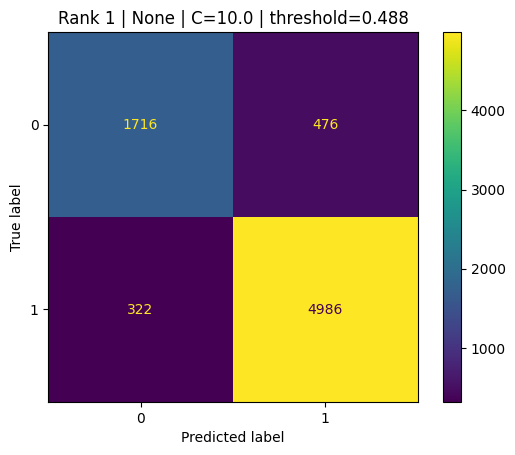

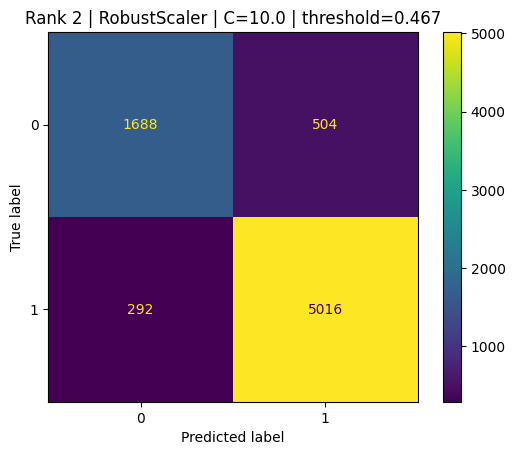

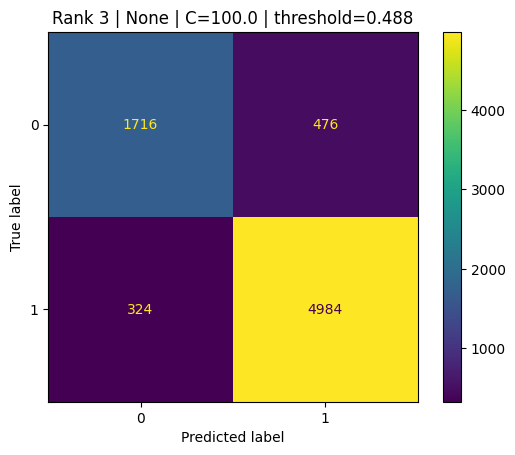

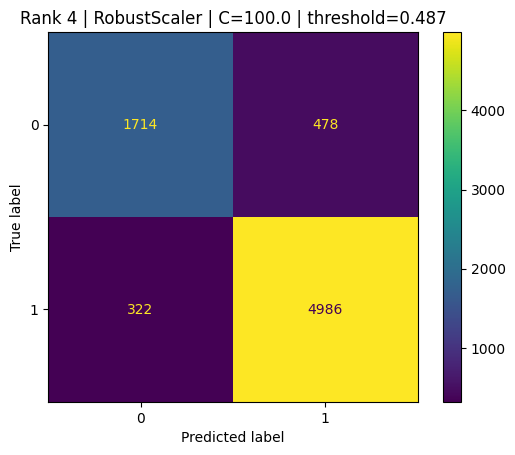

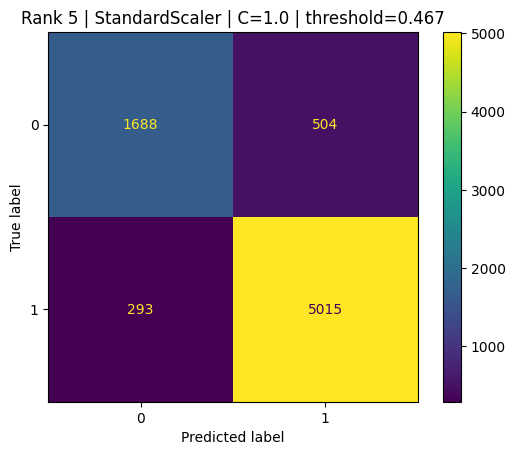

In [19]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# threshold tuning 후 Top 5
top5_models = [
    {'New_Rank': 1, 'Scaler': 'None',         'C': 10.0,  'class_weight': None, 'Threshold': 0.488},
    {'New_Rank': 2, 'Scaler': 'RobustScaler', 'C': 10.0,  'class_weight': None, 'Threshold': 0.467},
    {'New_Rank': 3, 'Scaler': 'None',         'C': 100.0, 'class_weight': None, 'Threshold': 0.488},
    {'New_Rank': 4, 'Scaler': 'RobustScaler', 'C': 100.0, 'class_weight': None, 'Threshold': 0.487},
    {'New_Rank': 5, 'Scaler': 'StandardScaler','C': 1.0,  'class_weight': None, 'Threshold': 0.467}
]

scaler_dict = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'None': 'passthrough'
}


for setting in top5_models:
    scaler = scaler_dict[setting['Scaler']]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', scaler, num_features),
            ('gender', OneHotEncoder(handle_unknown='ignore'), onehot_features),
            ('impact', OrdinalEncoder(categories=[['No', 'Yes']]), binary_features)
        ]
    )

    model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('classifier', LogisticRegression(
            C=setting['C'],
            class_weight=setting['class_weight'],
            max_iter=3000
        ))
    ])

    y_proba = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method='predict_proba'
    )[:, 1]

    y_pred = (y_proba >= setting['Threshold']).astype(int)

    cm = confusion_matrix(y, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(
        f"Rank {setting['New_Rank']} | {setting['Scaler']} | C={setting['C']} | threshold={setting['Threshold']}"
    )
    plt.show()